In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
plt.rcParams['font.family'] = 'Times New Roman'
#plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['mathtext.default'] = 'regular'
from scipy.optimize import curve_fit, minimize
from scipy.stats import norm, poisson
from scipy.special import gamma
from pathlib import Path
# import natural units:
import natural_units as nu
# multi-core/thread:
import concurrent.futures
import math
import matplotlib.ticker as ticker
from scipy.integrate import quad
from scipy.stats import chisquare
from scipy.stats import chi2
from concurrent.futures import ProcessPoolExecutor

def gaussian(x, mean, stddev):
    return  np.exp(-((x - mean) ** 2) / (2 * stddev ** 2)) / stddev / np.sqrt(2*np.pi)
def poisson(x, lambda_param):
    return np.exp(-lambda_param) * np.power(lambda_param, x) / gamma(x+1) #if not lambda_param < 1e-9 else
def log_poisson(x, lambda_param):
    if x > 0:
        return x * np.log(lambda_param) - lambda_param - (x*np.log(x) - x + np.log(2*np.pi*x)/2 + 1/12/x)  # 这 lambda_param 不能是0。如果很小，结果很负，摆动很大，注意。log(N!) = N*log(N) - N + log(2pi N)/2 + 1/12/N - ...
    else:
        return -lambda_param

In [2]:
input_file_dir = Path('./results/')
input_file_category = 'masked'
input_file_base = 'jw01121008001_02102_00001_nrs2'
input_file_name = input_file_base + '.txt'
#'../mask/results/blind2/jw01121012001_02102_00001_nrs2.txt'
#'../mask/results/blind2/jw01121124001_02102_00001_nrs2.txt'
#'../mask/results/blind2/jw01121120001_02102_00001_nrs2.txt'

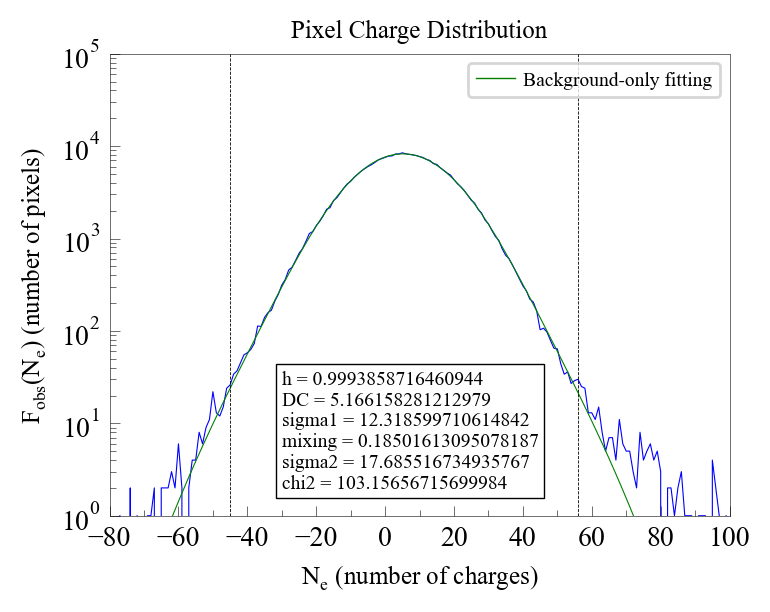

In [3]:
dn_min = -200
dn_max = 400
dn_range = range(dn_min, dn_max)
log_m_min  = -3
log_m_max  = 1
n_m    = 17   # From 1e-3  to 10 GeV
#log cs shift from the balloon line
cs_logshift_min = -3
cs_logshift_max = 0
cs_shift_numbers   = 25
m_grid      = np.logspace(log_m_min, log_m_max, n_m)
cs_logshift = np.linspace(cs_logshift_min, cs_logshift_max, cs_shift_numbers)
center_line = np.array([2.15504637e-23, 1.53030461e-23, 1.26359147e-23, 1.61669130e-23,
       2.40008514e-23, 4.03532201e-23, 6.95747264e-23, 1.40957345e-22,
       2.84518575e-22, 5.17381239e-22, 1.08351297e-21, 2.15203017e-21,
       4.12016417e-21, 7.78952222e-21, 1.45615810e-20, 2.70914228e-20,
       4.94000000e-20])
signal_gird = np.loadtxt('../SHIELDING_RESULT/signal_total_grid.txt')[:25]
N_dn     = np.loadtxt(input_file_dir / input_file_category / input_file_name)[:,1]
peak = np.argmax(N_dn) + dn_min
dn_min_likelihood = peak - 50
dn_max_likelihood = peak + 50 + 1 #难绷
total_count = np.sum(N_dn)
log_bottom = 0
for a in N_dn:
    if a > 20:
        log_bottom += a * np.log(a) - a
    else:
        log_bottom += np.log(math.factorial(int(a)))

# x[0]:peak_rescale  x[1]:peak_center  x[2]:read_noise  x[3]: second gaussian portion  x[4]: second gaussian
def BKD_double_G(x):
    bkd_analytical = np.zeros(dn_max-dn_min)
    for dn in range(0, 100):
        poisson_dn = poisson(dn, x[1])
        smear_min = dn_min
        smear_max = dn_max
        for dn_smear in range(smear_min, smear_max):
            bkd_analytical[dn_smear-dn_min] += poisson_dn * ((1-x[3])*gaussian(dn_smear, dn, x[2])+x[3]*gaussian(dn_smear, dn, x[4]))
    bkd_analytical = bkd_analytical * total_count * x[0]
    log_likelihood_0 = 0
    for k in range(dn_min_likelihood-dn_min,dn_max_likelihood-dn_min):
        log_likelihood_0 += log_poisson(N_dn[k], bkd_analytical[k])
    return log_likelihood_0-log_bottom, bkd_analytical
def log_likelihood_bkd_inverse_double_G(x):
    return -BKD_double_G(x)[0]
initial_guess_bkd = [1, peak, 13, 0.1, 18]
bounds = [(0.9,1.1),(0,np.max((1.5*peak, 20))),(8,16),(0,1),(16,30)]
fitting_result_bkd = minimize(log_likelihood_bkd_inverse_double_G, initial_guess_bkd, bounds=bounds, method= 'SLSQP')
bkd  = BKD_double_G(fitting_result_bkd.x)[1]
fig, ax = plt.subplots(figsize = (4,3), dpi = 200)
# 然后 chi_2 是个什么东西？  lambda=L(F_obs,F_model)/L(F_model,F_model)
# -2 log lambda
log_lambda_fitting = 0
chi_2 = 0
for k in range(dn_min_likelihood-dn_min,dn_max_likelihood-dn_min):
    log_lambda_fitting += log_poisson(N_dn[k], bkd[k]) - log_poisson(bkd[k], bkd[k])
    chi_2 += (N_dn[k]-bkd[k])**2 / bkd[k]
#print(-2 * log_lambda_fitting)
#print(chi_2)
fontsize = 9
plt.semilogy(dn_range, N_dn, color = 'blue', linewidth=0.4)
plt.semilogy(dn_range, bkd, color = 'green', linewidth=0.4)
plt.axvline(x=dn_min_likelihood, color='black', linestyle='--', linewidth = 0.3)
plt.axvline(x=dn_max_likelihood, color='black', linestyle='--', linewidth = 0.3)
ax.set_title('Pixel Charge Distribution', fontsize=fontsize)
ax.set_xlabel(r'$N_e$ (number of charges)', fontsize=fontsize)
ax.set_ylabel(r'$F_{obs}(N_e)$ (number of pixels)', fontsize=fontsize)
ax.set_xlim(-80,100)
ax.set_ylim(1,1e5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.tick_params(axis="both", direction="in", which = 'major', top=False, right=False, width = 0.2)
ax.tick_params(axis="both", direction="in", which = 'minor', top=False, right=False, width = 0.2)
ax.tick_params(labeltop=False, labelright=False)
ax.text(-30, 2, 'h = {}\nDC = {}\nsigma1 = {}\nmixing = {}\nsigma2 = {}\nchi2 = {}'.format(fitting_result_bkd.x[0],fitting_result_bkd.x[1],fitting_result_bkd.x[2],fitting_result_bkd.x[3],fitting_result_bkd.x[4],-2 * log_lambda_fitting), fontsize=fontsize-2, color='black', bbox=dict(facecolor='white', edgecolor='black', boxstyle='square',linewidth = 0.5))
for spine in ax.spines.values():
    spine.set_linewidth(0.2)  # 设置边框线宽为 2
legend_elements = [
    Line2D([0], [0], color='green', linestyle='-', linewidth = 0.5, label='Background-only fitting')
]
plt.legend(handles=legend_elements, fontsize=7, loc='upper right', handletextpad=0.4, frameon=True)
#plt.savefig("pixel_charge_distribution_after_pipeline_mask.pdf", format="pdf",bbox_inches="tight")
plt.show()

In [9]:
1- chi2.cdf(-2 * log_lambda_fitting, 96)

0.2904665616080073

卡方值均值: 99.65105497674423
卡方值方差: 198.66262585262928


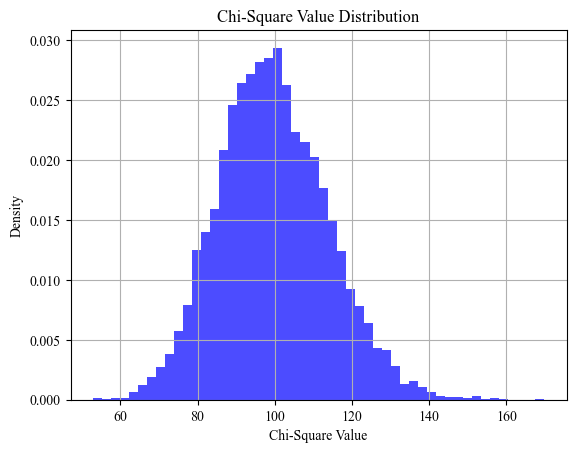

In [27]:
# 1. 定义原始概率分布 (例如，均匀分布)
original_distribution = bkd / total_count / (fitting_result_bkd.x)[0]  # PDF
original_distribution /= np.sum(original_distribution)   # 确保归一化
categories = np.arange(dn_min, dn_max)  # 分类数

# 2. 生成 1000 个样本
n_samples = 10000
sample_size = int(total_count * (fitting_result_bkd.x)[0])  # 每个样本的样本量

# 3. 计算每个样本的卡方值
chi_square_values = []
for j in range(n_samples):
    sample = np.random.choice(
    categories, 
    size=sample_size, 
    p=original_distribution)

    observed_counts = np.array([np.sum(sample == i) for i in categories])
    chi2 = 0
    for k in range(dn_min_likelihood-dn_min,dn_max_likelihood-dn_min):
        chi2 += (observed_counts[k]-bkd[k])**2 / bkd[k]
    chi_square_values.append(chi2)
    j += 1

# 转为 NumPy 数组
chi_square_values = np.array(chi_square_values)

# 4. 分析卡方分布
print("卡方值均值:", np.mean(chi_square_values))
print("卡方值方差:", np.var(chi_square_values))

# 绘制卡方值的分布直方图
plt.hist(chi_square_values, bins=50, density=True, alpha=0.7, color='blue')
plt.title("Chi-Square Value Distribution")
plt.xlabel("Chi-Square Value")
plt.ylabel("Density")
plt.grid(True)
plt.show()

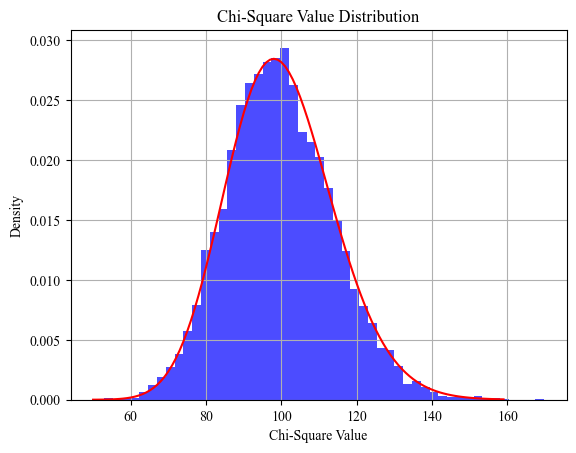

In [33]:
x = np.arange(50,160)
pdf = chi2.pdf(x, 100)
plt.hist(chi_square_values, bins=50, density=True, alpha=0.7, color='blue')
plt.plot(x, pdf, color = 'red')
plt.title("Chi-Square Value Distribution")
plt.xlabel("Chi-Square Value")
plt.ylabel("Density")
plt.grid(True)
plt.show()

In [12]:
1-chi2.cdf(110, 96)

0.1556202486006767

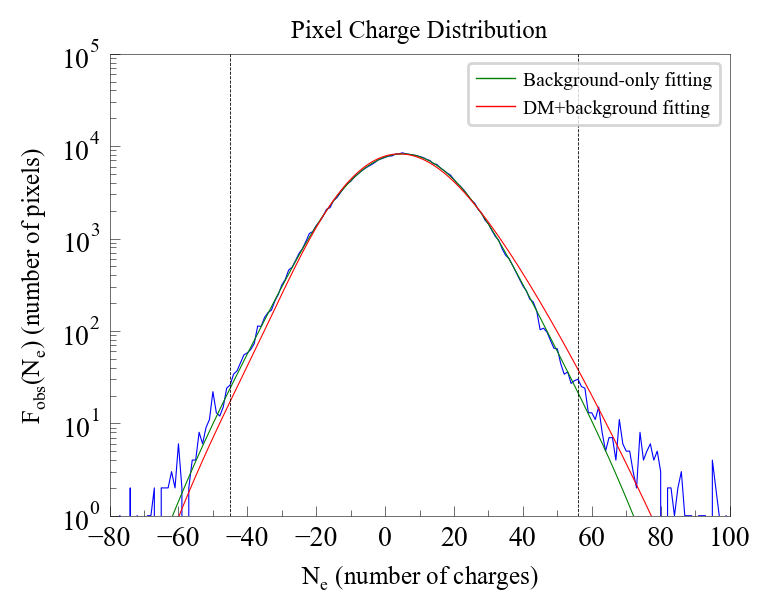

In [16]:
i = 16
j = 15
dm_poisson = np.loadtxt('../Monte_Carlo_Signal_Simulation/results_w_lin/DM_binned_shielding/'+ str(i) + '_' + str(j) + '.txt')
signal = signal_gird[cs_shift_numbers-1-j,i]
def BKD_DM(x):
    poisson_dn = np.zeros(dn_max-dn_min)
    bkd_dm_analytical = np.zeros(dn_max-dn_min)
    for dn in range(0, 100):
        for dn_dm in range(0, dn+1):
            poisson_dn[dn-dn_min] += dm_poisson[dn_dm-dn_min] * poisson(dn-dn_dm, x[1])
    for dn in range(0, dn_max):
        smear_min = dn_min
        smear_max = dn_max
        for dn_smear in range(smear_min, smear_max):
            bkd_dm_analytical[dn_smear-dn_min] += poisson_dn[dn-dn_min] * ((1-x[3])*gaussian(dn_smear, dn, x[2])+x[3]*gaussian(dn_smear, dn, x[4]))
    bkd_dm_analytical = bkd_dm_analytical * total_count * x[0]
    log_likelihood_dm = 0
    for k in range(dn_min_likelihood-dn_min,dn_max_likelihood-dn_min):
        log_likelihood_dm += log_poisson(N_dn[k], bkd_dm_analytical[k])
    return log_likelihood_dm-log_bottom, bkd_dm_analytical
def log_likelihood_bkddm_inverse(x):
    return -BKD_DM(x)[0]
initial_guess = [1, peak-signal, 13, 0.1, 18]
bounds = [(0.9,1.1),(np.min((0.5*(peak-signal),0)),np.max((1.5*peak, 20))),(8,16),(0,1),(16,30)]
# 用 minimize 函数寻找最小值
fitting_result_bkddm = minimize(log_likelihood_bkddm_inverse, initial_guess, bounds=bounds, method= 'SLSQP')
bkd_dm = BKD_DM(fitting_result_bkddm.x)[1]

fig, ax = plt.subplots(figsize = (4,3), dpi = 200)
fontsize = 9
plt.semilogy(dn_range, N_dn, color = 'blue', linewidth=0.4)
plt.semilogy(dn_range, bkd, color = 'green', linewidth=0.4)
plt.semilogy(dn_range, bkd_dm, color = 'red', linewidth=0.4)
plt.axvline(x=dn_min_likelihood, color='black', linestyle='--', linewidth = 0.3)
plt.axvline(x=dn_max_likelihood, color='black', linestyle='--', linewidth = 0.3)
ax.set_title('Pixel Charge Distribution', fontsize=fontsize)
ax.set_xlabel(r'$N_e$ (number of charges)', fontsize=fontsize)
ax.set_ylabel(r'$F_{obs}(N_e)$ (number of pixels)', fontsize=fontsize)
ax.set_xlim(-80,100)
ax.set_ylim(1,1e5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.tick_params(axis="both", direction="in", which = 'major', top=False, right=False, width = 0.2)
ax.tick_params(axis="both", direction="in", which = 'minor', top=False, right=False, width = 0.2)
ax.tick_params(labeltop=False, labelright=False)
for spine in ax.spines.values():
    spine.set_linewidth(0.2)  # 设置边框线宽为 2
legend_elements = [
    Line2D([0], [0], color='green', linestyle='-', linewidth = 0.5, label='Background-only fitting'),
    Line2D([0], [0], color='red', linestyle='-', linewidth = 0.5, label='DM+background fitting')
]
plt.legend(handles=legend_elements, fontsize=7, loc='upper right', handletextpad=0.4, frameon=True)
#plt.savefig("pixel_charge_distribution_after_pipeline_mask.pdf", format="pdf",bbox_inches="tight")
plt.show()

In [17]:
print(fitting_result_bkddm)
log_lambda_fitting = 0
chi_2 = 0
for k in range(dn_min_likelihood-dn_min,dn_max_likelihood-dn_min):
    log_lambda_fitting += log_poisson(N_dn[k], bkd_dm[k]) - log_poisson(bkd_dm[k], bkd_dm[k])
    chi_2 += (N_dn[k]-bkd_dm[k])**2 / bkd_dm[k]
print(-2 * log_lambda_fitting)
print(chi_2)

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 2053680.4910643892
       x: [ 9.997e-01  1.569e+00  1.138e+01  1.381e-01  1.706e+01]
     nit: 24
     jac: [-4.688e-02  1.562e-02  1.562e-02  1.250e-01  1.562e-02]
    nfev: 171
    njev: 24
1269.4438679605769
1230.9832241749182


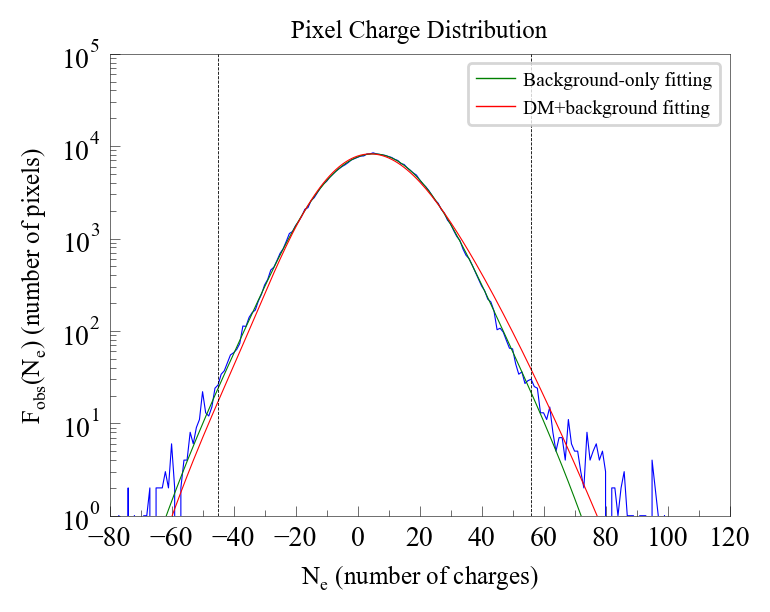

In [19]:
fig, ax = plt.subplots(figsize = (4,3), dpi = 200)
fontsize = 9
plt.semilogy(dn_range, N_dn, color = 'blue', linewidth=0.4)
plt.semilogy(dn_range, bkd, color = 'green', linewidth=0.4)
plt.semilogy(dn_range, bkd_dm, color = 'red', linewidth=0.4)
plt.axvline(x=dn_min_likelihood, color='black', linestyle='--', linewidth = 0.3)
plt.axvline(x=dn_max_likelihood, color='black', linestyle='--', linewidth = 0.3)
ax.set_title('Pixel Charge Distribution', fontsize=fontsize)
ax.set_xlabel(r'$N_e$ (number of charges)', fontsize=fontsize)
ax.set_ylabel(r'$F_{obs}(N_e)$ (number of pixels)', fontsize=fontsize)
ax.set_xlim(-80,120)
ax.set_ylim(1,1e5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.tick_params(axis="both", direction="in", which = 'major', top=False, right=False, width = 0.2)
ax.tick_params(axis="both", direction="in", which = 'minor', top=False, right=False, width = 0.2)
ax.tick_params(labeltop=False, labelright=False)
for spine in ax.spines.values():
    spine.set_linewidth(0.2)  # 设置边框线宽为 2
legend_elements = [
    Line2D([0], [0], color='green', linestyle='-', linewidth = 0.5, label='Background-only fitting'),
    Line2D([0], [0], color='red', linestyle='-', linewidth = 0.5, label='DM+background fitting')
]
plt.legend(handles=legend_elements, fontsize=7, loc='upper right', handletextpad=0.4, frameon=True)
#plt.savefig("pixel_charge_distribution_after_pipeline_mask.pdf", format="pdf",bbox_inches="tight")
plt.show()

In [ ]:
# 测试代码
def test_gaussian(x, mean = 0, stddev = 13):
    return  np.exp(-((x - mean) ** 2) / (2 * stddev ** 2)) / stddev / np.sqrt(2*np.pi)
test_x_range = np.arange(-20,21)
test_int_result = np.zeros(41)
for x in test_x_range:
    result, error = quad(test_gaussian, x-0.5, x+0.5)
    test_int_result[x+20] = result
1e4 * (test_int_result - test_gaussian(test_x_range))/np.sqrt(1e4*test_gaussian(test_x_range))

卡方值均值: 134.262
卡方值方差: 10110.489529333337


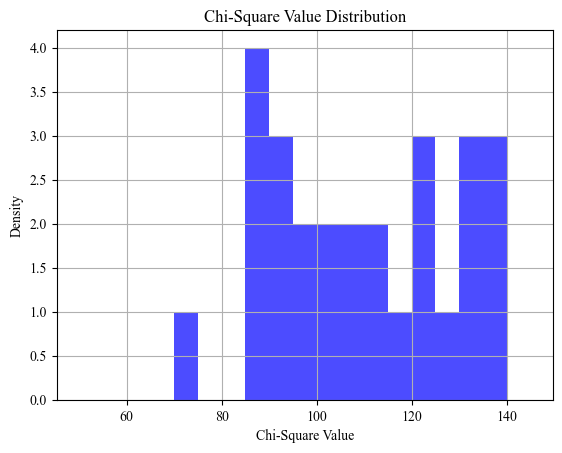

In [6]:
# 对于30个datasets而言：
# 转为 NumPy 数组
chi_square_values =[646.79, 114.84, 73.08, 103.16, 134.95, 130.79, 117.38,
                    90.97, 85.91, 120.45, 123.91, 90.17, 105.37, 88.06,
                    97.33, 127.59, 92.80, 167.33, 133.37, 107.14, 135.33,
                    88.55, 97.24, 120.98, 139.21, 102.45, 251.69, 114.25,
                    137.13, 89.64]
chi_square_values = np.array(chi_square_values)

# 4. 分析卡方分布
print("卡方值均值:", np.mean(chi_square_values))
print("卡方值方差:", np.var(chi_square_values))

# 绘制卡方值的分布直方图
plt.hist(chi_square_values, bins=np.arange(50,150,5), alpha=0.7, color='blue')
plt.title("Chi-Square Value Distribution")
plt.xlabel("Chi-Square Value")
plt.ylabel("Density")
plt.grid(True)
plt.show()

In [12]:
np.sum(chi_square_values<=100)

10